In [1]:
"""
Resume Evaluation Agent (LangGraph)
------------------------------------
Adapted from the essay-evaluation pattern. Instead of judging language/analysis/clarity,
this agent judges a resume against a specific Job Description (JD) on three parallel axes:

1. Keyword & Experience Matching  -> like an ATS/parser check (skills, tools, years of exp)
2. JD Matching                    -> overall fit ā role, responsibilities, seniority
3. Project Relevance              -> do the candidate's projects map to the job's actual work

Pipeline:
    PDF file --(pdfplumber / pypdf)--> raw text --(LLM structured extraction)--> parsed fields
        --(3 parallel LLM scoring nodes)--> final summarized verdict + score out of 10

Install deps:
    pip install langgraph langchain-openai pdfplumber pypdf python-dotenv
"""


"\nResume Evaluation Agent (LangGraph)\n------------------------------------\nAdapted from the essay-evaluation pattern. Instead of judging language/analysis/clarity,\nthis agent judges a resume against a specific Job Description (JD) on three parallel axes:\n\n1. Keyword & Experience Matching  -> like an ATS/parser check (skills, tools, years of exp)\n2. JD Matching                    -> overall fit ā role, responsibilities, seniority\n3. Project Relevance              -> do the candidate's projects map to the job's actual work\n\nPipeline:\n    PDF file --(pdfplumber / pypdf)--> raw text --(LLM structured extraction)--> parsed fields\n        --(3 parallel LLM scoring nodes)--> final summarized verdict + score out of 10\n\nInstall deps:\n    pip install langgraph langchain-openai pdfplumber pypdf python-dotenv\n"

In [2]:

from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional
from pydantic import BaseModel, Field
import operator

load_dotenv()

model = ChatOpenAI(model='gpt-4o-mini' , temperature=0)


In [3]:
# PDF -> raw text extraction
# pdfplumber preserves layout much better than pypdf (important for multi-column
# resumes, which are common). We try pdfplumber first and fall back to pypdf.
# ---------------------------------------------------------------------------
def extract_text_from_pdf(pdf_path: str) -> str:
    try:
        import pdfplumber
        text_chunks = []
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text() or ""
                text_chunks.append(page_text)
        text = "\n".join(text_chunks).strip()
        if text:
            return text
    except Exception:
        pass  # fall through to pypdf

    # Fallback: pypdf
    from pypdf import PdfReader
    reader = PdfReader(pdf_path)
    text_chunks = [page.extract_text() or "" for page in reader.pages]
    return "\n".join(text_chunks).strip()


In [4]:
# Structured output schemas
# ---------------------------------------------------------------------------
class ResumeEvaluationSchema(BaseModel):
    feedback: str = Field(description='Detailed feedback for this evaluation dimension')
    score: int = Field(description='Score out of 10', ge=0, le=10)

In [5]:
class ParsedResume(BaseModel):
    name: Optional[str] = Field(description='Candidate full name, if found')
    email: Optional[str] = Field(description='Candidate email, if found')
    phone: Optional[str] = Field(description='Candidate phone number, if found')
    total_experience_years: Optional[float] = Field(
        description='Best-estimate total years of professional experience, computed from work history dates'
    )
    skills: list[str] = Field(description='All technical and relevant soft skills listed or clearly implied')
    education: list[str] = Field(description='Education entries, e.g. "B.Tech CSE, XYZ University, 2021"')
    work_experience: list[str] = Field(
        description='One entry per job: "Company - Role - Duration - 1-line summary of responsibilities"'
    )
    projects: list[str] = Field(
        description='One entry per project: "Project name - tech used - 1-line summary of what it does"'
    )
    certifications: list[str] = Field(description='Certifications, if any; empty list if none')


structured_model = model.with_structured_output(ResumeEvaluationSchema)
resume_parser_model = model.with_structured_output(ParsedResume)


In [6]:
class ResumeState(TypedDict):
    resume_pdf_path: Optional[str]
    resume_text: str
    job_description: str
    job_role: str

    parsed_resume: ParsedResume

    keyword_experience_feedback: str
    keyword_experience_score: int

    jd_match_feedback: str
    jd_match_score: int

    project_feedback: str
    project_score: int

    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [7]:
# Node 0a: Load raw text (from PDF path if resume_text isn't already provided)
# ---------------------------------------------------------------------------
def load_resume_text(state: ResumeState):
    if state.get('resume_text'):
        return {}  # already have text, nothing to do
    if not state.get('resume_pdf_path'):
        raise ValueError("Provide either 'resume_text' or 'resume_pdf_path' in the initial state.")
    text = extract_text_from_pdf(state['resume_pdf_path'])
    return {'resume_text': text}


In [8]:
def parse_resume(state: ResumeState):
    prompt = f"""
Extract structured information from the following resume text. Be precise and only
include information that is actually present or can be reasonably inferred (e.g.
total years of experience from job dates). Leave fields empty/None if not found.

Resume text:
{state['resume_text']}
"""
    parsed = resume_parser_model.invoke(prompt)
    return {'parsed_resume': parsed}


In [9]:
def evaluate_keywords_experience(state: ResumeState):
    parsed = state['parsed_resume']
    prompt = f""" You are an ATS-style resume screener for the role: {state['job_role']}.
    
    Job Description:
    {state['job_description']}

    Candidate's extracted skills: {parsed.skills}
    Candidate's total experience (years, estimated): {parsed.total_experience_years}
    Candidate's work history:
    {chr(10).join(parsed.work_experience)}
    Candidate's certifications: {parsed.certifications}

    Task: Evaluate how well the resume's KEYWORDS and EXPERIENCE match what the job requires.
    Specifically check:
    - Presence of required technical skills / tools / frameworks mentioned in the JD
    - Years of relevant experience vs what the JD asks for (if specified)
    - Domain/industry experience alignment
    - Any critical keyword gaps that would cause an ATS or recruiter to reject the resume

    Give detailed feedback listing matched keywords, missing keywords, and experience gaps,
    then assign a score out of 10 for keyword/experience match."""  
    
    output = structured_model.invoke(prompt)
    return {
        'keyword_experience_feedback': output.feedback,
        'keyword_experience_score': output.score,
        'individual_scores': [output.score]
    }

In [10]:
def evaluate_jd_match(state: ResumeState):
    parsed = state['parsed_resume']
    prompt = f"""
You are a senior recruiter evaluating overall fit for the role: {state['job_role']}.

Job Description:
{state['job_description']}

Candidate summary:
- Total experience (years, estimated): {parsed.total_experience_years}
- Work history: {chr(10).join(parsed.work_experience)}
- Education: {parsed.education}
- Skills: {parsed.skills}

Task: Evaluate how well the CANDIDATE'S PROFILE as a whole matches the job description --
not just keywords, but role responsibilities, seniority level, scope of past work, and
whether their overall trajectory fits this position.

Give detailed feedback on alignment/misalignment with the JD's core responsibilities,
then assign a score out of 10 for JD match.
"""
    output = structured_model.invoke(prompt)
    return {
        'jd_match_feedback': output.feedback,
        'jd_match_score': output.score,
        'individual_scores': [output.score]
    }



In [11]:
#project evaluate new node
class ProjectRelevanceSchema(BaseModel):
    core_requirements_from_jd: list[str] = Field(
        description='List the 5-8 most important technical requirements/skills from the JD (e.g. "YOLO", "multi-object tracking")'
    )
    requirements_covered_by_projects: list[str] = Field(
        description='Subset of the above list that is ACTUALLY demonstrated by the listed projects, with real evidence. Empty list if none.'
    )
    reasoning: str = Field(description='Brief explanation of the matching above, including any shallow/toy-level projects discounted')
    score: int = Field(
        description='Score out of 10, computed as round(10 * len(requirements_covered_by_projects) / len(core_requirements_from_jd)). Must match this formula exactly.',
        ge=0, le=10
    )

project_relevance_model = model.with_structured_output(ProjectRelevanceSchema)

def evaluate_projects(state: ResumeState):
    parsed = state['parsed_resume']
    project_list = parsed.projects if parsed.projects else []
    prompt = f"""
You are a strict, skeptical hiring manager for the role: {state['job_role']}.

Job Description:
{state['job_description']}

Candidate's projects ({len(project_list)} total listed):
{chr(10).join(project_list) if project_list else "No projects listed."}

Step 1: Extract the 5-8 most important, specific technical requirements from the JD
(concrete tools/techniques, not vague categories -- e.g. "YOLO" not "computer vision").

Step 2: For EACH requirement, check if the listed projects provide real, substantive evidence
of it (not just a keyword mention elsewhere on the resume -- it must show up IN a project
description). A single shallow or tutorial-level project only counts as covering a requirement
if it clearly and specifically demonstrates that exact skill.

Step 3: Compute the score as EXACTLY: round(10 * covered_count / total_requirements_count).
Do not adjust this number based on "potential" or "transferable skills" -- only count what
the projects concretely demonstrate.

If no projects are listed, or none demonstrate any core requirement, the score must be 0.
"""
    output = project_relevance_model.invoke(prompt)
    return {
        'project_feedback': f"{output.reasoning} (Covered: {output.requirements_covered_by_projects} out of {output.core_requirements_from_jd})",
        'project_score': output.score,
        'individual_scores': [output.score]
    }

In [12]:

# Node 3: Project Relevance
# ---------------------------------------------------------------------------
"""def evaluate_projects(state: ResumeState):
    parsed = state['parsed_resume']
    prompt = f 
You are a hiring manager for the role: {state['job_role']}.

Job Description:
{state['job_description']}

Candidate's projects:
{chr(10).join(parsed.projects) if parsed.projects else "No projects listed."}

Task: Evaluate the PROJECTS/WORK SAMPLES listed in the resume specifically for relevance
to the day-to-day responsibilities implied by the job description. Consider:
- Do the projects demonstrate the actual skills/technologies this job needs?
- Is there evidence of the scale/complexity expected for this role?
- Are there any standout projects that strongly signal fit, or notable gaps?

Give detailed feedback, then assign a score out of 10 for project relevance.

    output = structured_model.invoke(prompt)
    return {
        'project_feedback': output.feedback,
        'project_score': output.score, 
        'individual_scores': [output.score]
    }
    """

'def evaluate_projects(state: ResumeState):\n    parsed = state[\'parsed_resume\']\n    prompt = f \nYou are a hiring manager for the role: {state[\'job_role\']}.\n\nJob Description:\n{state[\'job_description\']}\n\nCandidate\'s projects:\n{chr(10).join(parsed.projects) if parsed.projects else "No projects listed."}\n\nTask: Evaluate the PROJECTS/WORK SAMPLES listed in the resume specifically for relevance\nto the day-to-day responsibilities implied by the job description. Consider:\n- Do the projects demonstrate the actual skills/technologies this job needs?\n- Is there evidence of the scale/complexity expected for this role?\n- Are there any standout projects that strongly signal fit, or notable gaps?\n\nGive detailed feedback, then assign a score out of 10 for project relevance.\n\n    output = structured_model.invoke(prompt)\n    return {\n        \'project_feedback\': output.feedback,\n        \'project_score\': output.score, \n        \'individual_scores\': [output.score]\n    }\

In [13]:
def final_evaluation(state: ResumeState):
    parsed = state['parsed_resume']
    prompt = f"""
Based on the following three evaluations of {parsed.name or "the candidate"}'s resume
for the role "{state['job_role']}", write a concise overall summary of the candidate's
suitability. End with a one-line verdict (e.g. "Strong fit", "Moderate fit", "Weak fit").

Keyword & Experience Match feedback:
{state['keyword_experience_feedback']}

JD Match feedback:
{state['jd_match_feedback']}

Project Relevance feedback:
{state['project_feedback']}
"""
    overall_feedback = model.invoke(prompt).content
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}



In [14]:
graph = StateGraph(ResumeState)
graph.add_node('load_resume_text', load_resume_text)
graph.add_node('parse_resume', parse_resume)
graph.add_node('evaluate_keywords_experience', evaluate_keywords_experience)
graph.add_node('evaluate_jd_match', evaluate_jd_match)
graph.add_node('evaluate_projects', evaluate_projects)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START, 'load_resume_text')
graph.add_edge('load_resume_text', 'parse_resume')
graph.add_edge('parse_resume', 'evaluate_keywords_experience')
graph.add_edge('parse_resume', 'evaluate_jd_match')
graph.add_edge('parse_resume', 'evaluate_projects')
graph.add_edge('evaluate_keywords_experience', 'final_evaluation')
graph.add_edge('evaluate_jd_match', 'final_evaluation')
graph.add_edge('evaluate_projects', 'final_evaluation')
graph.add_edge('final_evaluation', END)

workflow = graph.compile()

In [15]:
if __name__ == "__main__":
    JOB_ROLE = "AI/ML Engineer - Computer Vision"
    JOB_DESCRIPTION = """We're looking for an experienced AI/ML Engineer (3+ years) with strong expertise in Computer Vision, Deep Learning, and Production AI.

    Key skills:
    • Python, PyTorch/TensorFlow
    • YOLO, OpenCV, Detectron2/MMDetection
    • Multi-object tracking, pose estimation, video analytics
    • FastAPI, Docker, CUDA, TensorRT, ONNX
    • AWS/Azure/GCP
    • LLMs, VLMs, RAG, LangChain, Hugging Face
    • MLOps, MLflow, Weights & Biases"""  # your JD

    initial_state = {
        "resume_pdf_path": r"C:\Users\ADMIN\Desktop\Langgraph\digvijaySignhMalik_260226_094238.pdf",
        "resume_text": "",
        "job_description": JOB_DESCRIPTION,
        "job_role": JOB_ROLE,
    }

    result = workflow.invoke(initial_state)

    print("Parsed candidate:", result["parsed_resume"].name)
    print()
    print(f"Keyword & Experience Match : {result['keyword_experience_score']} / 10")
    print(f"JD Match                   : {result['jd_match_score']} / 10")
    print(f"Project Relevance          : {result['project_score']} / 10")
    print()
    print(f"Overall Average Score      : {result['avg_score']} / 10")
    print()
    print(result["overall_feedback"])

Parsed candidate: D I G V I J A Y S I N G H M A L I K

Keyword & Experience Match : 2 / 10
JD Match                   : 1 / 10
Project Relevance          : 5 / 10

Overall Average Score      : 2.6666666666666665 / 10

D I G V I J A Y S I N G H M A L I K's resume reveals significant gaps in alignment with the requirements for the AI/ML Engineer - Computer Vision role. While the candidate possesses some relevant skills such as Python, FastAPI, and AWS, they lack essential experience in AI/ML, particularly in Computer Vision, with 0 years of relevant experience compared to the required 3+ years. The absence of critical tools and frameworks like PyTorch, TensorFlow, YOLO, and OpenCV further diminishes their suitability. Although there is a project involving YOLO, it is insufficient to demonstrate the breadth of experience needed for this position. Overall, the candidate does not meet the core qualifications necessary for the role.

Verdict: Weak fit.


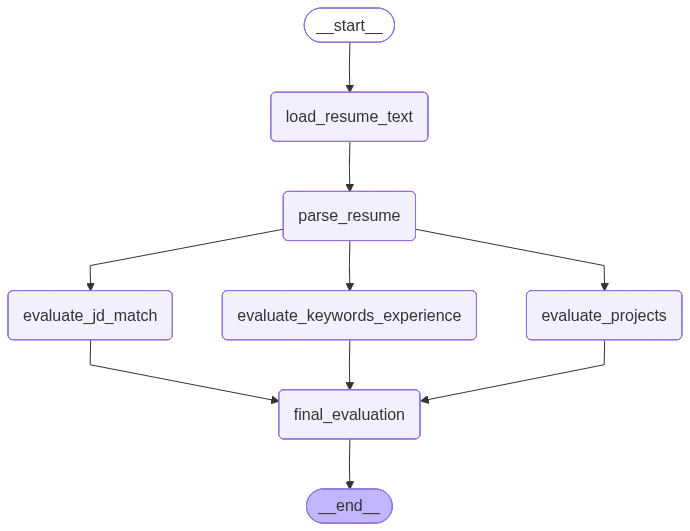

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())